<a href="https://colab.research.google.com/github/sgulyano/CMKL41-685/blob/main/41_685lab_3Dcnn.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Video Classification with a 3D CNN (UCF101)

A demo of video classification using a `Conv3D` neural network based on [A Closer Look at Spatiotemporal Convolutions for Action Recognition](https://ieeexplore.ieee.org/document/8578773) by D. Tran et al. (2017).

We will use a public **5-class subset of UCF101** rather than downloading the complete UCF101 dataset.

In [1]:
# Check TensorFlow and GPU
import tensorflow as tf

print("TensorFlow:", tf.__version__)
print("GPU(s):", tf.config.list_physical_devices("GPU"))

TensorFlow: 2.20.0
GPU(s): [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


## 1. Download a small UCF101 subset

This is the same 5-class UCF101 subset used by Keras video-classification examples.

In [2]:
!wget -q --show-progress \
  https://github.com/sayakpaul/Action-Recognition-in-TensorFlow/releases/download/v1.0.0/ucf101_top5.tar.gz

!tar -xf ucf101_top5.tar.gz

!ls -lh

ucf101_top5.tar.gz  100%[===================>] 427.12M  31.3MB/s    in 13s     
total 428M
drwxr-xr-x 1 root root 4.0K Sep  4 13:32 sample_data
drwxr-xr-x 2 root root  12K May 27  2021 test
-rw-r--r-- 1 root root 8.1K May 27  2021 test.csv
drwxr-xr-x 2 root root  36K May 27  2021 train
-rw-r--r-- 1 root root  22K May 27  2021 train.csv
-rw-r--r-- 1 root root 428M Dec  7  2021 ucf101_top5.tar.gz


## 2. Inspect the dataset

In [3]:
import os
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import cv2

from sklearn.model_selection import train_test_split

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

train_df = pd.read_csv("train.csv")
test_df = pd.read_csv("test.csv")

print("Training videos:", len(train_df))
print("Test videos:", len(test_df))
print("\nClasses:", sorted(train_df["tag"].unique()))
display(train_df.head())

print("\nTraining examples per class:")
display(train_df["tag"].value_counts().sort_index())

Training videos: 594
Test videos: 224

Classes: ['CricketShot', 'PlayingCello', 'Punch', 'ShavingBeard', 'TennisSwing']


,video_name,tag
0,v_CricketShot_g08_c01.avi,CricketShot
1,v_CricketShot_g08_c02.avi,CricketShot
2,v_CricketShot_g08_c03.avi,CricketShot
3,v_CricketShot_g08_c04.avi,CricketShot
4,v_CricketShot_g08_c05.avi,CricketShot



Training examples per class:


,count
tag,
CricketShot,118
PlayingCello,120
Punch,121
ShavingBeard,118
TennisSwing,117


## 3. Video → fixed-size clip

Neural networks need a fixed tensor shape. We represent every video by:

**16 frames × 96 × 96 pixels × 3 color channels**

Rather than taking only the first 16 frames, we **uniformly sample 16 frames across the video**.

In [4]:
NUM_FRAMES = 16
IMG_SIZE = 96

def load_video(path, num_frames=NUM_FRAMES, img_size=IMG_SIZE):
    # Uniformly sample frames and return a (T,H,W,C) float32 tensor.
    cap = cv2.VideoCapture(path)

    if not cap.isOpened():
        raise ValueError(f"Could not open video: {path}")

    frame_count = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))

    if frame_count <= 0:
        cap.release()
        return np.zeros((num_frames, img_size, img_size, 3), dtype=np.float32)

    frame_ids = np.linspace(0, max(frame_count - 1, 0), num_frames).astype(int)

    frames = []
    for frame_id in frame_ids:
        cap.set(cv2.CAP_PROP_POS_FRAMES, int(frame_id))
        ok, frame = cap.read()

        if not ok:
            if frames:
                frame = (frames[-1] * 255).astype(np.uint8)
                frame = cv2.cvtColor(frame, cv2.COLOR_RGB2BGR)
            else:
                frame = np.zeros((img_size, img_size, 3), dtype=np.uint8)

        frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
        frame = cv2.resize(frame, (img_size, img_size))
        frame = frame.astype(np.float32) / 255.0
        frames.append(frame)

    cap.release()
    return np.stack(frames)

example_row = train_df.sample(1, random_state=SEED).iloc[0]
example_path = os.path.join("train", example_row["video_name"])
example_clip = load_video(example_path)

print("Class:", example_row["tag"])
print("Clip shape:", example_clip.shape)

Class: CricketShot
Clip shape: (16, 96, 96, 3)


### Visualize sampled frames

The temporal dimension is explicit: the CNN receives a sequence of frames, not a single image.

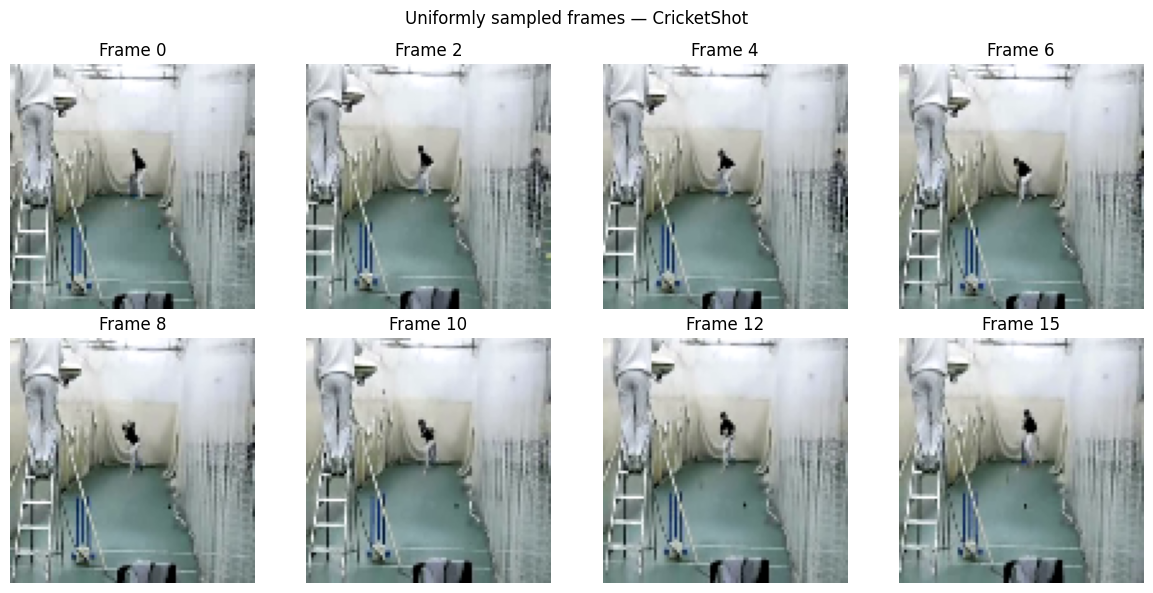

In [5]:
fig, axes = plt.subplots(2, 4, figsize=(12, 6))
for ax, i in zip(axes.ravel(), np.linspace(0, NUM_FRAMES-1, 8).astype(int)):
    ax.imshow(example_clip[i])
    ax.set_title(f"Frame {i}")
    ax.axis("off")

plt.suptitle(f"Uniformly sampled frames — {example_row['tag']}")
plt.tight_layout()
plt.show()

## 4. Labels and train/validation split

The archive already provides train and test sets. We split part of the training set
into a validation set.

`FAST_DEMO=True` limits the amount of data so the notebook is convenient for a live lecture.
Set it to `False` to use the whole provided training subset.

In [6]:
classes = sorted(train_df["tag"].unique())
class_to_id = {name: i for i, name in enumerate(classes)}
id_to_class = {i: name for name, i in class_to_id.items()}

print(class_to_id)

train_part, val_part = train_test_split(
    train_df,
    test_size=0.20,
    random_state=SEED,
    stratify=train_df["tag"]
)

FAST_DEMO = True
MAX_TRAIN_PER_CLASS = 40
MAX_VAL_PER_CLASS = 10
MAX_TEST_PER_CLASS = 15

def limit_per_class(df, n):
    if n is None:
        return df.reset_index(drop=True)

    parts = []
    for _, group in df.groupby("tag"):
        parts.append(group.sample(min(len(group), n), random_state=SEED))
    return pd.concat(parts).reset_index(drop=True)

if FAST_DEMO:
    train_part = limit_per_class(train_part, MAX_TRAIN_PER_CLASS)
    val_part = limit_per_class(val_part, MAX_VAL_PER_CLASS)
    test_part = limit_per_class(test_df, MAX_TEST_PER_CLASS)
else:
    test_part = test_df.reset_index(drop=True)

print("Train:", len(train_part))
print("Validation:", len(val_part))
print("Test:", len(test_part))

{'CricketShot': 0, 'PlayingCello': 1, 'Punch': 2, 'ShavingBeard': 3, 'TennisSwing': 4}
Train: 200
Validation: 50
Test: 75


## 5. Build an on-the-fly video data loader

Loading every decoded video into RAM at once is wasteful. This `Sequence` reads and decodes
only the videos needed for the current mini-batch.

In [7]:
class VideoSequence(tf.keras.utils.Sequence):
    def __init__(self, dataframe, root_dir, batch_size=4, shuffle=True, **kwargs):
        super().__init__(**kwargs)
        self.df = dataframe.reset_index(drop=True).copy()
        self.root_dir = root_dir
        self.batch_size = batch_size
        self.shuffle = shuffle
        self.indices = np.arange(len(self.df))
        self.on_epoch_end()

    def __len__(self):
        return int(np.ceil(len(self.df) / self.batch_size))

    def __getitem__(self, batch_index):
        inds = self.indices[
            batch_index * self.batch_size:
            (batch_index + 1) * self.batch_size
        ]

        batch_x = []
        batch_y = []

        for i in inds:
            row = self.df.iloc[i]
            path = os.path.join(self.root_dir, row["video_name"])
            batch_x.append(load_video(path))
            batch_y.append(class_to_id[row["tag"]])

        return (
            np.asarray(batch_x, dtype=np.float32),
            np.asarray(batch_y, dtype=np.int32)
        )

    def on_epoch_end(self):
        if self.shuffle:
            np.random.shuffle(self.indices)

BATCH_SIZE = 4

train_seq = VideoSequence(train_part, "train", BATCH_SIZE, shuffle=True)
val_seq   = VideoSequence(val_part,   "train", BATCH_SIZE, shuffle=False)
test_seq  = VideoSequence(test_part,  "test",  BATCH_SIZE, shuffle=False)

x_batch, y_batch = train_seq[0]
print("Input batch:", x_batch.shape)
print("Labels:", y_batch.shape)

Input batch: (4, 16, 96, 96, 3)
Labels: (4,)


## 6. Build 3D CNN

Here the input shape is:

`(16, 96, 96, 3) = (time, height, width, channels)`

In [8]:
from tensorflow import keras
from tensorflow.keras import layers

NUM_CLASSES = len(classes)

model = keras.Sequential([
    layers.Input(shape=(NUM_FRAMES, IMG_SIZE, IMG_SIZE, 3)),

    layers.Conv3D(
        16, kernel_size=(3, 3, 3),
        strides=(1, 2, 2),
        padding="same"
    ),
    layers.BatchNormalization(),
    layers.ReLU(),
    layers.MaxPool3D(pool_size=(2, 2, 2)),

    layers.Conv3D(32, (3, 3, 3), padding="same"),
    layers.BatchNormalization(),
    layers.ReLU(),
    layers.MaxPool3D(pool_size=(2, 2, 2)),

    layers.Conv3D(64, (3, 3, 3), padding="same"),
    layers.BatchNormalization(),
    layers.ReLU(),
    layers.MaxPool3D(pool_size=(2, 2, 2)),

    layers.GlobalAveragePooling3D(),
    layers.Dropout(0.4),
    layers.Dense(NUM_CLASSES, activation="softmax")
])

model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv3d (Conv3D)                 │ (None, 16, 48, 48, 16) │         1,312 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 16, 48, 48, 16) │            64 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu (ReLU)                    │ (None, 16, 48, 48, 16) │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling3d (MaxPooling3D)    │ (None, 8, 24, 24, 16)  │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv3d_1 (Conv3D)               │ (None, 8, 24, 24, 32)  │        13,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 8, 24, 24, 32)  │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_1 (ReLU)                  │ (None, 8, 24, 24, 32)  │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling3d_1 (MaxPooling3D)  │ (None, 4, 12, 12, 32)  │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv3d_2 (Conv3D)               │ (None, 4, 12, 12, 64)  │        55,360 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 4, 12, 12, 64)  │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_2 (ReLU)                  │ (None, 4, 12, 12, 64)  │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling3d_2 (MaxPooling3D)  │ (None, 2, 6, 6, 64)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling3d        │ (None, 64)             │             0 │
│ (GlobalAveragePooling3D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 5)              │           325 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 71,301 (278.52 KB)

 Trainable params: 71,077 (277.64 KB)

 Non-trainable params: 224 (896.00 B)

`Conv3D` layer allows the network to model **appearance + short-term motion**.

## 7. Train

In [9]:
EPOCHS = 5

callbacks = [
    keras.callbacks.EarlyStopping(
        monitor="val_accuracy",
        patience=2,
        restore_best_weights=True
    )
]

history = model.fit(
    train_seq,
    validation_data=val_seq,
    epochs=EPOCHS,
    callbacks=callbacks
)

Epoch 1/5
50/50 ━━━━━━━━━━━━━━━━━━━━ 51s 849ms/step - accuracy: 0.3550 - loss: 1.6467 - val_accuracy: 0.2000 - val_loss: 1.9977
Epoch 2/5
50/50 ━━━━━━━━━━━━━━━━━━━━ 43s 867ms/step - accuracy: 0.5150 - loss: 1.1637 - val_accuracy: 0.2200 - val_loss: 2.3644
Epoch 3/5
50/50 ━━━━━━━━━━━━━━━━━━━━ 39s 782ms/step - accuracy: 0.5950 - loss: 1.0714 - val_accuracy: 0.3000 - val_loss: 2.2955
Epoch 4/5
50/50 ━━━━━━━━━━━━━━━━━━━━ 50s 1s/step - accuracy: 0.6700 - loss: 0.9185 - val_accuracy: 0.2000 - val_loss: 4.1694
Epoch 5/5
50/50 ━━━━━━━━━━━━━━━━━━━━ 41s 817ms/step - accuracy: 0.6100 - loss: 1.0004 - val_accuracy: 0.3400 - val_loss: 2.6978


## 8. Plot the learning curves

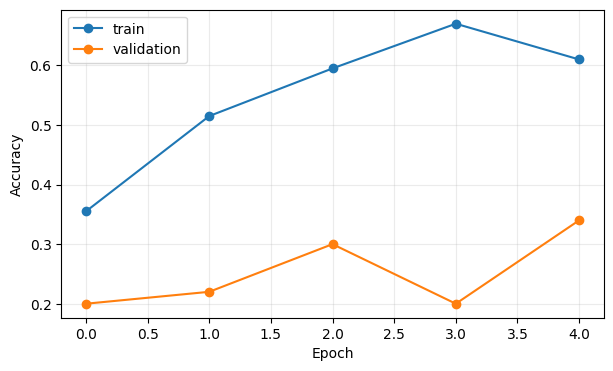

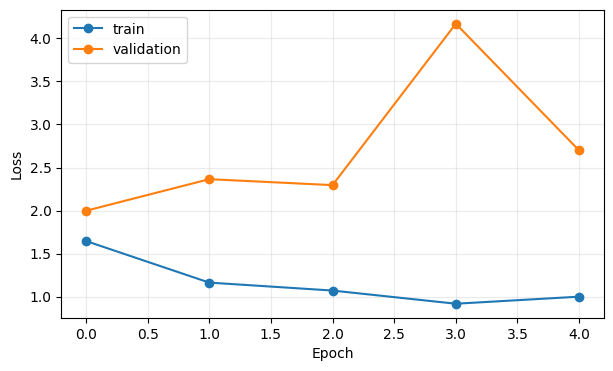

In [10]:
history_df = pd.DataFrame(history.history)

plt.figure(figsize=(7, 4))
plt.plot(history_df["accuracy"], marker="o", label="train")
plt.plot(history_df["val_accuracy"], marker="o", label="validation")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(alpha=0.25)
plt.show()

plt.figure(figsize=(7, 4))
plt.plot(history_df["loss"], marker="o", label="train")
plt.plot(history_df["val_loss"], marker="o", label="validation")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(alpha=0.25)
plt.show()

## 9. Evaluate on unseen test videos

In [11]:
test_loss, test_accuracy = model.evaluate(test_seq, verbose=1)
print(f"Test accuracy: {test_accuracy:.3f}")

19/19 ━━━━━━━━━━━━━━━━━━━━ 12s 620ms/step - accuracy: 0.2800 - loss: 3.0707
Test accuracy: 0.280


## 10. Predict one video

We display the original video and then run the exact same 16-frame preprocessing pipeline.

Ground truth: ShavingBeard

Predictions:
ShavingBeard         0.993
TennisSwing          0.003
CricketShot          0.003
PlayingCello         0.002
Punch                0.000


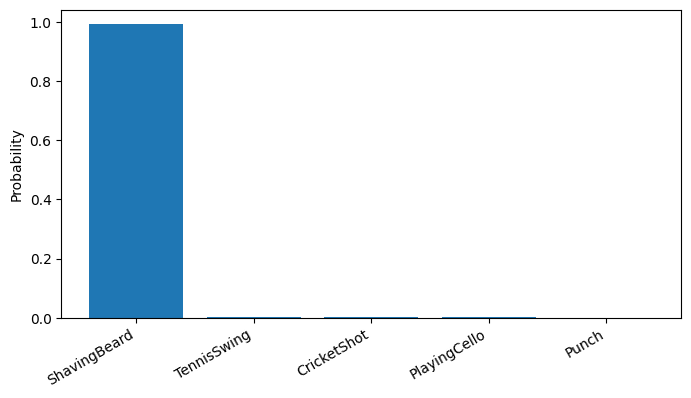

In [26]:
from IPython.display import Video, display

sample = test_part.sample(1, random_state=50).iloc[0]
sample_path = os.path.join("test", sample["video_name"])

print("Ground truth:", sample["tag"])

clip = load_video(sample_path)
probs = model.predict(clip[None, ...], verbose=0)[0]

order = np.argsort(probs)[::-1]

print("\nPredictions:")
for i in order:
    print(f"{id_to_class[i]:20s} {probs[i]:.3f}")

plt.figure(figsize=(8, 4))
plt.bar([id_to_class[i] for i in order], probs[order])
plt.ylabel("Probability")
plt.xticks(rotation=30, ha="right")
plt.show()

In [27]:
from moviepy.editor import *

clip=VideoFileClip(sample_path)
clip.ipython_display(width=280)

Moviepy - Building video __temp__.mp4.
MoviePy - Writing audio in __temp__TEMP_MPY_wvf_snd.mp3


MoviePy - Done.
Moviepy - Writing video __temp__.mp4



Moviepy - Done !
Moviepy - video ready __temp__.mp4


## References

- UCF101: Soomro, Zamir, and Shah, *UCF101: A Dataset of 101 Human Actions Classes From Videos in The Wild*.
- Keras video-classification examples use this public 5-class UCF101 subset.
- A Closer Look at Spatiotemporal Convolutions for Action Recognition by D. Tran et al. (2017)